**Library imports**

The required libraries are imported for data preparation, stationarity confirmation, VAR estimation, diagnostic checking, forecasting, evaluation and visualisation.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR

from sklearn.metrics import mean_squared_error, mean_absolute_error

**Load the model-ready dataset**

The completed stationary multivariate dataset is loaded from `var_data.csv`. A working copy is created so that the imported data remain unchanged.

In [3]:
var_data_original = pd.read_csv("/content/drive/MyDrive/MSc_Dissertation/datasets/final_datasets/var_data.csv")
var_data = var_data_original.copy()

var_data.head()

,Date,Inflation,Interest,GDP_Growth,Exchange_Rate_Change,Liquidity_Growth
0,2003-10-31,0.049032,2.75,0.713227,1.345797,0.672905
1,2003-11-30,0.167685,2.50,-4.800947,0.265478,1.676012
2,2003-12-31,0.563951,2.50,0.719166,0.264523,3.591035
3,2004-01-31,0.537447,2.50,3.042076,0.784533,2.564209
4,2004-02-29,1.086085,2.50,1.079214,-0.619494,-0.634991


**Establish the time-series index**

The `Date` column is converted to a datetime format and established as the index. This allows the observations to be validated and handled as a monthly time series.

In [4]:
# Convert the Date column to datetime format

var_data["Date"] = pd.to_datetime(var_data["Date"],format="%Y-%m-%d",errors="raise")

# Use the dates as the DataFrame index

var_data = var_data.set_index("Date")

var_data.head()

,Inflation,Interest,GDP_Growth,Exchange_Rate_Change,Liquidity_Growth
Date,,,,,
2003-10-31,0.049032,2.75,0.713227,1.345797,0.672905
2003-11-30,0.167685,2.50,-4.800947,0.265478,1.676012
2003-12-31,0.563951,2.50,0.719166,0.264523,3.591035
2004-01-31,0.537447,2.50,3.042076,0.784533,2.564209
2004-02-29,1.086085,2.50,1.079214,-0.619494,-0.634991


**Validate the model-ready dataset**

The dataset is checked for the expected dimensions, variables, date range, chronological order, duplicated dates, missing or infinite values, and continuity of the monthly observations.

In [5]:
# Define the expected variables and complete monthly date range

expected_columns = ["Inflation","Interest","GDP_Growth","Exchange_Rate_Change","Liquidity_Growth"]

expected_months = pd.date_range(
    start=var_data.index.min(),
    end=var_data.index.max(),
    freq="ME")

missing_months = expected_months.difference(var_data.index)

# Check the structure and quality of the VAR dataset

print("Shape:", var_data.shape)
print("Columns correct:", list(var_data.columns) == expected_columns)
print("Start date:", var_data.index.min())
print("End date:", var_data.index.max())
print("Chronologically ordered:", var_data.index.is_monotonic_increasing)
print("Duplicated dates:", var_data.index.duplicated().sum())
print("Missing values:", var_data.isna().sum().sum())
print("Infinite values:", np.isinf(var_data.to_numpy()).sum())
print("Missing months:", missing_months.tolist())

print()
print("Data types:")
print(var_data.dtypes)

Shape: (267, 5)
Columns correct: True
Start date: 2003-10-31 00:00:00
End date: 2025-12-31 00:00:00
Chronologically ordered: True
Duplicated dates: 0
Missing values: 0
Infinite values: 0
Missing months: []

Data types:
Inflation               float64
Interest                float64
GDP_Growth              float64
Exchange_Rate_Change    float64
Liquidity_Growth        float64
dtype: object


Create the training and test sets

The data are divided using the fixed forecast boundary. The training set ends in December 2024, while the 12 observations from 2025 are reserved for final out-of-sample evaluation and will not be used during model selection.

In [6]:
# Set an explicit monthly frequency

var_data = var_data.asfreq("ME")

# Split the data into training and test periods

var_train = var_data.loc["2003-10-31":"2024-12-31"].copy()

var_test = var_data.loc["2025-01-31":"2025-12-31"].copy()

# Confirm the size and date range of each dataset

print("Training shape:", var_train.shape)
print("Training period:",var_train.index.min(),"to",var_train.index.max())

print()
print("Test shape:", var_test.shape)
print("Test period:",var_test.index.min(),"to",var_test.index.max())

print()
print("Total observations assigned:",len(var_train) + len(var_test))

Training shape: (255, 5)
Training period: 2003-10-31 00:00:00 to 2024-12-31 00:00:00

Test shape: (12, 5)
Test period: 2025-01-31 00:00:00 to 2025-12-31 00:00:00

Total observations assigned: 267


Confirm stationarity in the training data

The Augmented Dickey–Fuller test is applied to each training series as a training-period confirmation of stationarity. At the 5% significance level, a p-value below 0.05 leads to rejection of the null hypothesis of a unit root. The completed variable transformations are not reconsidered at this stage.

In [7]:
# Apply the ADF test to each training variable

adf_results = []

for column in var_train.columns:
    result = adfuller(
        var_train[column],
        regression="c",
        autolag="AIC")

    adf_results.append({
        "Variable": column,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Lags Used": result[2],
        "Observations": result[3],
        "Critical Value (5%)": result[4]["5%"],
        "Stationary (5%)": "Yes" if result[1] < 0.05 else "No"})

# Create the ADF results table

adf_train_results = pd.DataFrame(adf_results)

adf_train_results.round(4)

,Variable,ADF Statistic,p-value,Lags Used,Observations,Critical Value (5%),Stationary (5%)
0,Inflation,-3.4347,0.0098,13,241,-2.8736,Yes
1,Interest,-3.2051,0.0197,2,252,-2.8731,Yes
2,GDP_Growth,-8.0788,0.0000,7,247,-2.8733,Yes
3,Exchange_Rate_Change,-13.1695,0.0000,0,254,-2.8730,Yes
4,Liquidity_Growth,-4.0445,0.0012,14,240,-2.8737,Yes


All five training series had ADF p-values below 0.05, so the unit-root null hypothesis was rejected for each variable. Inflation and Interest were therefore retained in levels, while the transformed GDP Growth, Exchange Rate Change and Liquidity Growth series were confirmed as stationary.

**Examine VAR lag-selection criteria**

AIC, BIC, HQIC and FPE are examined for lag orders 1–12 using only the training data. Lower values indicate the preferred lag order under each criterion. The maximum of 12 lags is a project-specific bound that covers up to one year of monthly dynamics while limiting model complexity.

In [8]:
# Create the VAR model using the training data

var_model = VAR(var_train)

# Compare lag orders from 1 to 12

lag_order_results = var_model.select_order(
    maxlags=12,
    trend="c")

lag_criteria = (
    pd.DataFrame(lag_order_results.ics)
    .rename(columns=str.upper)
    .loc[1:12]
    .copy())

lag_criteria.index.name = "Lag"

lag_criteria.round(6)

,AIC,BIC,HQIC,FPE
Lag,,,,
1,-1.495660,-1.064418,-1.321960,0.224112
2,-2.313260,-1.522649,-1.994809,0.098969
3,-2.317974,-1.167995,-1.854774,0.098567
4,-2.185611,-0.676263,-1.577660,0.112652
5,-2.081193,-0.212477,-1.328492,0.125295
6,-1.996299,0.231785,-1.098848,0.136790
7,-1.918032,0.669421,-0.875831,0.148518
8,-1.868773,1.078048,-0.681822,0.156847
9,-1.767516,1.538674,-0.435815,0.174749


**Identify the criterion-supported lag orders**

The lag-selection criteria did not agree. BIC and HQIC selected two lags, while AIC and FPE selected three. VAR(2) and VAR(3) were therefore retained for estimation and diagnostic testing. Limiting the candidates to these selected lag orders was a project-specific decision, not a general VAR requirement.

In [9]:
lag_selection_summary = pd.DataFrame({
    "Selected Lag": lag_criteria.idxmin().astype(int),
    "Minimum Criterion Value": lag_criteria.min()})

candidate_lags = sorted(lag_selection_summary["Selected Lag"].unique().tolist())

display(lag_selection_summary.round(6))
print("\nDistinct candidate lag orders:", candidate_lags)

,Selected Lag,Minimum Criterion Value
AIC,3,-2.317974
BIC,2,-1.522649
HQIC,2,-1.994809
FPE,3,0.098567



Distinct candidate lag orders: [2, 3]


**Estimate the candidate VAR models**

The two criterion-supported candidates, VAR(2) and VAR(3), are estimated using only the training data and with a constant term. Both models contain the same five endogenous variables. They are retained for diagnostic assessment before the final lag order is selected.

In [10]:
# Estimate each candidate VAR model

candidate_models = {}

for lag in candidate_lags:
    candidate_models[lag] = VAR(var_train).fit(
        maxlags=lag,
        trend="c")

# Summarise the estimated candidate models

candidate_estimation_summary = pd.DataFrame([
    {
        "Model": "VAR({})".format(lag),
        "Lag Order": results.k_ar,
        "Observations Used": results.nobs,
        "Equations": results.neqs,
        "Parameters per Equation": results.df_model}

    for lag, results in candidate_models.items()]).set_index("Model")

candidate_estimation_summary

,Lag Order,Observations Used,Equations,Parameters per Equation
Model,,,,
VAR(2),2,253,5,11
VAR(3),3,252,5,16


**Check the stability of the candidate models**

Each candidate is checked for stability before diagnostic assessment and forecasting. A stable VAR has companion-matrix eigenvalues inside the unit circle. As `statsmodels` reports inverse characteristic roots, the corresponding reported root moduli must be greater than one.

In [11]:
# Check the stability of each candidate VAR model

stability_summary = pd.DataFrame([
    {
        "Model": "VAR({})".format(lag),
        "Stable": results.is_stable(verbose=False),
        "Minimum Inverse-Root Modulus": np.min(
            np.abs(results.roots))}
    for lag, results in candidate_models.items()]).set_index("Model")

stability_summary.round(6)

,Stable,Minimum Inverse-Root Modulus
Model,,
VAR(2),True,1.136169
VAR(3),True,1.074419


**Assess residual whiteness**

A multivariate Portmanteau test was applied to each stable candidate to assess residual autocorrelation. The test used 12 lags, covering one year of monthly residual behaviour and exceeding both model orders. The standard asymptotic version was used.

The null hypothesis is that residual autocorrelations up to lag 12 are jointly zero. A p-value below 0.05 indicates remaining residual autocorrelation.

In [12]:
# Test each candidate for residual autocorrelation

whiteness_horizon = 12
whiteness_results = []

for lag, results in candidate_models.items():
    whiteness_test = results.test_whiteness(
        nlags=whiteness_horizon,
        signif=0.05,
        adjusted=False)

    whiteness_results.append({
        "Model": "VAR({})".format(lag),
        "Test Horizon": whiteness_horizon,
        "Test Statistic": whiteness_test.test_statistic,
        "Degrees of Freedom": whiteness_test.df,
        "Critical Value (5%)": whiteness_test.crit_value,
        "p-value": whiteness_test.pvalue,
        "Reject H0 (5%)": (
            "Yes" if whiteness_test.pvalue < 0.05 else "No")
    })

# Create the residual whiteness summary table

whiteness_summary = (
    pd.DataFrame(whiteness_results)
    .set_index("Model"))

whiteness_summary.round(6)

,Test Horizon,Test Statistic,Degrees of Freedom,Critical Value (5%),p-value,Reject H0 (5%)
Model,,,,,,
VAR(2),12,310.401193,250,287.881501,0.005555,Yes
VAR(3),12,258.865052,225,260.992120,0.060122,No


**Select the final VAR model**

Both candidate models were stable. However, the Portmanteau test rejected residual whiteness for VAR(2), indicating remaining autocorrelation. The null hypothesis was not rejected for VAR(3).

VAR(3) was therefore selected as the final model, also supported by AIC and FPE. Selection used only the training data, without using the 2025 test observations.

In [13]:
# Retain VAR(3) as the final model

selected_lag = 3
final_var_model = candidate_models[selected_lag]

print("Selected model:", "VAR({})".format(selected_lag))
print("Training observations used:", final_var_model.nobs)
print("Stable:", final_var_model.is_stable(verbose=False))

print(
    "Residual-whiteness p-value:",
    round(whiteness_summary.loc["VAR({})".format(selected_lag),"p-value"],6))

Selected model: VAR(3)
Training observations used: 252
Stable: True
Residual-whiteness p-value: 0.060122


**Generate the recursive VAR forecast**

Starting from the final three training observations, VAR(3) generated 12 monthly forecasts for all five variables. No 2025 observations were used as forecasting inputs. Previously transformed variables remained on their stationary growth or change scales.

Although the model forecast all variables jointly, accuracy was evaluated only for inflation, the dissertation’s target variable.

In [14]:
# Set the forecast horizon to match the test period

forecast_steps = len(var_test)

# Use the final three training observations as initial values

forecast_input = var_train.to_numpy()[-final_var_model.k_ar:]

# Generate recursive forecasts for all five variables

var_forecast_values = final_var_model.forecast(y=forecast_input,steps=forecast_steps)

var_forecast = pd.DataFrame(var_forecast_values,index=var_test.index,columns=var_train.columns)

print("Forecast input shape:", forecast_input.shape)
print("Forecast output shape:", var_forecast.shape)

var_forecast.round(6)

Forecast input shape: (3, 5)
Forecast output shape: (12, 5)


,Inflation,Interest,GDP_Growth,Exchange_Rate_Change,Liquidity_Growth
Date,,,,,
2025-01-31,0.157464,4.928001,0.592221,-0.253930,2.315288
2025-02-28,0.150805,4.859167,0.249872,0.091332,1.890801
2025-03-31,0.193445,4.789103,0.240848,-0.176915,2.056376
2025-04-30,0.221891,4.714580,0.429426,-0.084576,1.719127
2025-05-31,0.227557,4.639524,0.453049,-0.022123,1.477106
2025-06-30,0.231946,4.565159,0.389060,-0.068309,1.362689
2025-07-31,0.228435,4.491800,0.364490,-0.070252,1.260786
2025-08-31,0.226043,4.419828,0.366504,-0.058409,1.207389
2025-09-30,0.225412,4.349712,0.364596,-0.056335,1.192129


**Align actual and forecast inflation**

The forecast inflation values are aligned with the corresponding observations in the 2025 test set. Although the VAR forecasts all five variables jointly, evaluation is restricted to inflation because it is the target variable of the dissertation.

In [15]:
# Compare actual and forecast inflation during the test period

actual_inflation = var_test["Inflation"].copy()
forecast_inflation = var_forecast["Inflation"].copy()

inflation_forecast_comparison = pd.DataFrame({
    "Actual Inflation": actual_inflation,
    "VAR Forecast": forecast_inflation})

# Confirm that the comparison data are complete and aligned

print("Observations:", len(inflation_forecast_comparison))
print("Dates aligned:",actual_inflation.index.equals(forecast_inflation.index))
print("Missing values:",inflation_forecast_comparison.isna().sum().sum())

inflation_forecast_comparison.round(6)

Observations: 12
Dates aligned: True
Missing values: 0


,Actual Inflation,VAR Forecast
Date,,
2025-01-31,-0.093318,0.157464
2025-02-28,0.188012,0.150805
2025-03-31,0.810159,0.193445
2025-04-30,0.318066,0.221891
2025-05-31,-0.056475,0.227557
2025-06-30,0.128680,0.231946
2025-07-31,0.231431,0.228435
2025-08-31,-0.290254,0.226043
2025-09-30,0.011152,0.225412


**Evaluate the inflation forecast**

Inflation forecast accuracy was evaluated using RMSE, MAE and MAPE, matching the SARIMA evaluation. Lower values indicate smaller forecast errors.

MAPE was reported for consistency but interpreted cautiously because negative and near-zero inflation values can produce very large percentage errors, even when absolute errors are relatively small.

In [16]:
# Extract actual and forecast inflation values

actual_values = inflation_forecast_comparison[
    "Actual Inflation"].to_numpy()

forecast_values = inflation_forecast_comparison[
    "VAR Forecast"].to_numpy()

# Calculate RMSE and MAE

var_rmse = np.sqrt(mean_squared_error(actual_values,forecast_values))

var_mae = mean_absolute_error(actual_values,forecast_values)

# Exclude exact zeros because percentage error is undefined

nonzero_actual = actual_values != 0

var_mape = (np.mean(np.abs((actual_values[nonzero_actual] - forecast_values[nonzero_actual]) / actual_values[nonzero_actual]))* 100)

print("VAR RMSE: {:.4f}".format(var_rmse))
print("VAR MAE: {:.4f}".format(var_mae))
print("VAR MAPE: {:.2f}%".format(var_mape))

print("Observations used for MAPE:", nonzero_actual.sum(), "of", len(actual_values))

VAR RMSE: 0.2852
VAR MAE: 0.2149
VAR MAPE: 292.88%
Observations used for MAPE: 12 of 12


**Visualise the inflation forecast**

Actual monthly inflation is compared with the recursive VAR(3) forecast across the 12-month test period. The zero line helps identify months in which actual inflation was negative. No forecast intervals are added because they are not part of the agreed evaluation framework.

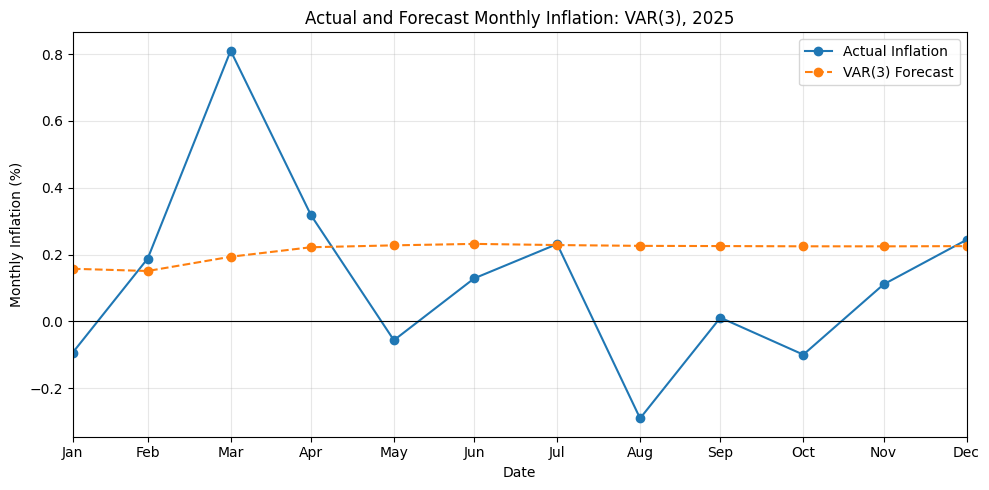

In [17]:
# Plot actual and forecast monthly inflation

fig, ax = plt.subplots(figsize=(10, 5))

comparison_dates = inflation_forecast_comparison.index

ax.plot(
    comparison_dates,
    inflation_forecast_comparison["Actual Inflation"],
    marker="o",
    label="Actual Inflation")

ax.plot(
    comparison_dates,
    inflation_forecast_comparison["VAR Forecast"],
    marker="o",
    linestyle="--",
    label="VAR(3) Forecast")

ax.axhline(
    0,
    color="black",
    linewidth=0.8)

ax.set(
    title="Actual and Forecast Monthly Inflation: VAR(3), 2025",
    xlabel="Date",
    ylabel="Monthly Inflation (%)",
    xlim=(comparison_dates.min(), comparison_dates.max()),
    xticks=comparison_dates,
    xticklabels=comparison_dates.strftime("%b"))

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Compare SARIMA and VAR forecast accuracy**

The final SARIMA and VAR models were compared over the same 12-month test period in 2025 using RMSE, MAE and MAPE.

Each model retained its established training dataset. SARIMA used the univariate series from January 1995 to December 2024, while VAR used multivariate data from October 2003 to December 2024. The comparison therefore reflects the forecasting designs used in this study rather than models trained with identical information.

RMSE and MAE were the main evaluation measures. MAPE was reported for consistency but interpreted cautiously because several actual inflation values were negative or close to zero.

In [18]:
# Compare forecast accuracy across the final models

model_comparison = pd.DataFrame({
    "Model": [
        "SARIMA(1,0,1)(1,0,1,12)",
        "VAR(3)"],
    "RMSE": [
        0.1767,
        var_rmse],
    "MAE": [
        0.1275,
        var_mae],
    "MAPE (%)": [
        99.34,
        var_mape]}).set_index("Model")

display(
    model_comparison.round({
        "RMSE": 4,
        "MAE": 4,
        "MAPE (%)": 2}))

print("Lowest RMSE:", model_comparison["RMSE"].idxmin())

print("Lowest MAE:", model_comparison["MAE"].idxmin())

,RMSE,MAE,MAPE (%)
Model,,,
"SARIMA(1,0,1)(1,0,1,12)",0.1767,0.1275,99.34
VAR(3),0.2852,0.2149,292.88


Lowest RMSE: SARIMA(1,0,1)(1,0,1,12)
Lowest MAE: SARIMA(1,0,1)(1,0,1,12)


**Summary**

A stationary VAR was estimated using inflation, the policy interest rate, GDP growth, exchange-rate change and liquidity growth. Lag-selection criteria supported VAR(2) and VAR(3). Both were stable, but the Portmanteau test found remaining residual autocorrelation in VAR(2). VAR(3) was therefore selected using only the training data, although its residual-whiteness result was close to the 5% threshold.

VAR(3) generated recursive forecasts for all 12 months of 2025 without using observed test values as inputs. For inflation, it recorded an RMSE of 0.2852 and an MAE of 0.2149. Its forecasts were relatively smooth and missed several large monthly changes in actual inflation.

Over the same period, SARIMA achieved a lower RMSE of 0.1767 and MAE of 0.1275. It therefore produced better inflation forecasts under the modelling designs used in this study. MAPE also favoured SARIMA, but it was not treated as primary evidence because actual inflation included negative and near-zero values.

This result applies only to the selected models, variables, transformations, training periods and 12-month test period. It does not show that multivariate information is generally unhelpful for inflation forecasting.

#Appendix: Direct comparison of SARIMA and VAR forecasts

The final SARIMA and VAR inflation forecasts are plotted against the same actual observations from January to December 2025. The values used below were copied from the final model outputs for graphical comparison. The reported accuracy measures remain those calculated from the original model outputs.

In [19]:
comparison_dates = pd.date_range(
    start="2025-01-31",
    end="2025-12-31",
    freq="ME"
)

forecast_comparison = pd.DataFrame(
    {
        "Actual Inflation": [
            -0.0933, 0.1880, 0.8102, 0.3181,
            -0.0565, 0.1287, 0.2314, -0.2903,
            0.0112, -0.0996, 0.1108, 0.2441
        ],
        "SARIMA Forecast": [
            0.0531, 0.1371, 0.6185, 0.0967,
            0.0404, 0.0756, 0.2709, 0.1919,
            0.0485, 0.0060, 0.0410, 0.2085
        ],
        "VAR(3) Forecast": [
            0.157464, 0.150805, 0.193445, 0.221891,
            0.227557, 0.231946, 0.228435, 0.226043,
            0.225412, 0.224700, 0.224587, 0.225246
        ]
    },
    index=comparison_dates)

forecast_comparison.index.name = "Date"

print("Observations:", len(forecast_comparison))
print("Missing values:", forecast_comparison.isna().sum().sum())

forecast_comparison.round(4)

Observations: 12
Missing values: 0


,Actual Inflation,SARIMA Forecast,VAR(3) Forecast
Date,,,
2025-01-31,-0.0933,0.0531,0.1575
2025-02-28,0.1880,0.1371,0.1508
2025-03-31,0.8102,0.6185,0.1934
2025-04-30,0.3181,0.0967,0.2219
2025-05-31,-0.0565,0.0404,0.2276
2025-06-30,0.1287,0.0756,0.2319
2025-07-31,0.2314,0.2709,0.2284
2025-08-31,-0.2903,0.1919,0.2260
2025-09-30,0.0112,0.0485,0.2254


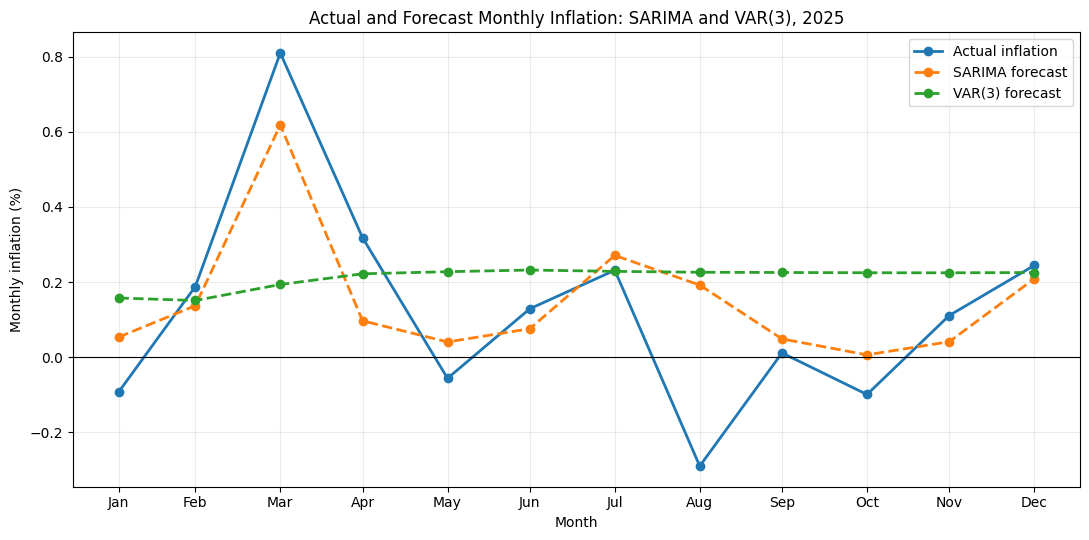

In [20]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(
    forecast_comparison.index,
    forecast_comparison["Actual Inflation"],
    marker="o",
    linewidth=2,
    label="Actual inflation"
)

ax.plot(
    forecast_comparison.index,
    forecast_comparison["SARIMA Forecast"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="SARIMA forecast"
)

ax.plot(
    forecast_comparison.index,
    forecast_comparison["VAR(3) Forecast"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="VAR(3) forecast"
)

ax.axhline(0, color="black", linewidth=0.8)

ax.set_title("Actual and Forecast Monthly Inflation: SARIMA and VAR(3), 2025")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly inflation (%)")

ax.set_xticks(forecast_comparison.index)
ax.set_xticklabels(forecast_comparison.index.strftime("%b"))

ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Appendix A — Complete out-of-sample forecasts

This appendix reports the actual monthly inflation values and the forecasts produced by the selected SARIMA and VAR(3) models for January–December 2025. All forecasts were generated using information available up to December 2024.

Forecast errors are calculated as actual inflation minus forecast inflation. The SARIMA prediction limits are included because they were generated during the SARIMA analysis. The VAR evaluation used point forecasts, so VAR prediction intervals are not reported.

In [21]:
# Create the complete out-of-sample forecast table for Appendix A

appendix_a_forecasts = pd.DataFrame({
    "Date": pd.to_datetime([
        "2025-01-31",
        "2025-02-28",
        "2025-03-31",
        "2025-04-30",
        "2025-05-31",
        "2025-06-30",
        "2025-07-31",
        "2025-08-31",
        "2025-09-30",
        "2025-10-31",
        "2025-11-30",
        "2025-12-31"
    ]),
    "Actual Inflation": [
        -0.0933,
        0.1880,
        0.8102,
        0.3181,
        -0.0565,
        0.1287,
        0.2314,
        -0.2903,
        0.0112,
        -0.0996,
        0.1108,
        0.2441
    ],
    "SARIMA Forecast": [
        0.0531,
        0.1371,
        0.6185,
        0.0967,
        0.0404,
        0.0756,
        0.2709,
        0.1919,
        0.0485,
        0.0060,
        0.0410,
        0.2085
    ],
    "Lower 95% PI": [
        -0.5280,
        -0.4563,
        0.0139,
        -0.5184,
        -0.5845,
        -0.5584,
        -0.3716,
        -0.4585,
        -0.6093,
        -0.6589,
        -0.6304,
        -0.4690
    ],
    "Upper 95% PI": [
        0.6343,
        0.7304,
        1.2231,
        0.7118,
        0.6653,
        0.7096,
        0.9134,
        0.8423,
        0.7064,
        0.6708,
        0.7124,
        0.8860
    ],
    "VAR(3) Forecast": [
        0.1575,
        0.1508,
        0.1934,
        0.2219,
        0.2276,
        0.2319,
        0.2284,
        0.2260,
        0.2254,
        0.2247,
        0.2246,
        0.2252
    ]
})

# Calculate signed forecast errors using the definition from Section 5.2.6

appendix_a_forecasts["SARIMA Error"] = (
    appendix_a_forecasts["Actual Inflation"]
    - appendix_a_forecasts["SARIMA Forecast"]
)

appendix_a_forecasts["VAR(3) Error"] = (
    appendix_a_forecasts["Actual Inflation"]
    - appendix_a_forecasts["VAR(3) Forecast"]
)

# Arrange the columns in the order used in the appendix

appendix_a_forecasts = appendix_a_forecasts[[
    "Date",
    "Actual Inflation",
    "SARIMA Forecast",
    "Lower 95% PI",
    "Upper 95% PI",
    "SARIMA Error",
    "VAR(3) Forecast",
    "VAR(3) Error"
]]

# Confirm that the table contains the complete 2025 period

assert len(appendix_a_forecasts) == 12
assert appendix_a_forecasts["Date"].is_unique
assert appendix_a_forecasts["Date"].is_monotonic_increasing
assert appendix_a_forecasts.isna().sum().sum() == 0

# Prepare a clean display version

appendix_a_display = appendix_a_forecasts.copy()

appendix_a_display["Date"] = (
    appendix_a_display["Date"].dt.strftime("%Y-%m-%d")
)

display(
    appendix_a_display.style
    .format({
        "Actual Inflation": "{:.4f}",
        "SARIMA Forecast": "{:.4f}",
        "Lower 95% PI": "{:.4f}",
        "Upper 95% PI": "{:.4f}",
        "SARIMA Error": "{:.4f}",
        "VAR(3) Forecast": "{:.4f}",
        "VAR(3) Error": "{:.4f}"
    })
    .hide(axis="index")
)

Date,Actual Inflation,SARIMA Forecast,Lower 95% PI,Upper 95% PI,SARIMA Error,VAR(3) Forecast,VAR(3) Error
2025-01-31,-0.0933,0.0531,-0.5280,0.6343,-0.1464,0.1575,-0.2508
2025-02-28,0.1880,0.1371,-0.4563,0.7304,0.0509,0.1508,0.0372
2025-03-31,0.8102,0.6185,0.0139,1.2231,0.1917,0.1934,0.6168
2025-04-30,0.3181,0.0967,-0.5184,0.7118,0.2214,0.2219,0.0962
2025-05-31,-0.0565,0.0404,-0.5845,0.6653,-0.0969,0.2276,-0.2841
2025-06-30,0.1287,0.0756,-0.5584,0.7096,0.0531,0.2319,-0.1032
2025-07-31,0.2314,0.2709,-0.3716,0.9134,-0.0395,0.2284,0.0030
2025-08-31,-0.2903,0.1919,-0.4585,0.8423,-0.4822,0.2260,-0.5163
2025-09-30,0.0112,0.0485,-0.6093,0.7064,-0.0373,0.2254,-0.2142
2025-10-31,-0.0996,0.0060,-0.6589,0.6708,-0.1056,0.2247,-0.3243
